**Name:** Sadeen Alsabbagh

# Python Tutorial Assessment

**BMI 500: Introduction to Ethical Data Science and Informatics**

The Leibniz formula<sup>1</sup>

$$
\frac{\pi}{4} = \arctan 1 = \sum_{k=0}^{\infty} \frac{(-1)^k}{2k+1} = 1 - \frac{1}{3} + \frac{1}{5} - \frac{1}{7} + \dots
$$

is one of the first formulas for calculating $\pi$ that was based on infinite series instead of geometrical techniques. While this series converges much more slowly than many other series, it can still provide several digits of $\pi$ within seconds.

**Problem 1.** Write a function in Python 3.x that, given an integer $n$, returns the sum of the first $n$ terms of the series in the Leibniz formula.

In [1]:
# Problem 1 - answer
def leibniz_sum(n):
    """Return the sum of the first n terms of the Leibniz series (approximates pi/4)."""
    total = 0.0
    sign = 1  # the first term is added, then the sign alternates
    for k in range(n):
        total += sign / (2 * k + 1)
        sign = -sign
    return total


print(leibniz_sum(10))
print(4 * leibniz_sum(10))  # approximation to pi

0.7604599047323508
3.0418396189294032


**Problem 2.** For each of the following items, write a function in Python 3.x that, given an integer $n$, returns the sum of the first $n$ terms of the series in the Leibniz formula.

**a.** Use a for-loop and an if-statement with the modulo operator `%` to determine whether to add or subtract each term.

In [2]:
# Problem 2a - answer
def leibniz_modulo(n):
    """Leibniz partial sum using a for-loop, an if-statement, and the modulo operator."""
    total = 0.0
    for k in range(n):
        if k % 2 == 0:  # even k: add the term
            total += 1 / (2 * k + 1)
        else:           # odd k: subtract the term
            total -= 1 / (2 * k + 1)
    return total


print(leibniz_modulo(10))

0.7604599047323508


**b.** Use a for-loop with the quantity `(-1)**n` to determine whether to add or subtract each term.

In [3]:
# Problem 2b - answer
def leibniz_power(n):
    """Leibniz partial sum using a for-loop and (-1)**k for the sign of each term."""
    total = 0.0
    for k in range(n):
        total += (-1) ** k / (2 * k + 1)  # the sign depends on the loop index k
    return total


print(leibniz_power(10))

0.7604599047323508


**c.** Construct a Python list and compute the sum of the terms in the list.

In [4]:
# Problem 2c - answer
def leibniz_list(n):
    """Leibniz partial sum by building a Python list of the terms and summing it."""
    terms = [(-1) ** k / (2 * k + 1) for k in range(n)]
    return sum(terms)


print(leibniz_list(10))

0.7604599047323508


**d.** Construct a Python set and compute the sum of the terms in the set.

In [5]:
# Problem 2d - answer
def leibniz_set(n):
    """Leibniz partial sum by building a Python set of the terms and summing it.

    Every term has a different value, so no terms are lost when they are put in a set.
    """
    terms = {(-1) ** k / (2 * k + 1) for k in range(n)}
    return sum(terms)


print(leibniz_set(10))

0.7604599047323508


**e.** Construct a Python dictionary and compute the sum of the terms in the dictionary.

In [6]:
# Problem 2e - answer
def leibniz_dict(n):
    """Leibniz partial sum by building a dictionary {k: term} and summing its values."""
    terms = {k: (-1) ** k / (2 * k + 1) for k in range(n)}
    return sum(terms.values())


print(leibniz_dict(10))

0.7604599047323508


**f.** Construct a NumPy array and compute the sum of the terms in the array.

In [7]:
# Problem 2f - answer
import numpy as np


def leibniz_numpy(n):
    """Leibniz partial sum by building a NumPy array of the terms and summing it."""
    k = np.arange(n)
    terms = (-1.0) ** k / (2 * k + 1)
    return float(np.sum(terms))


print(leibniz_numpy(10))

0.7604599047323506


**g.** Construct a NumPy array, use array indexing to compute the sum of the positive terms in the array, use array indexing to compute the sum of the negative terms in the array, and add the two sums together. You can write `x[::2]` to access the first, third, etc. terms and `x[1::2]` to access the second, fourth, etc. terms.

In [8]:
# Problem 2g - answer
def leibniz_numpy_split(n):
    """Leibniz partial sum: sum the positive and negative terms separately with indexing."""
    k = np.arange(n)
    x = (-1.0) ** k / (2 * k + 1)
    positive_sum = np.sum(x[::2])   # first, third, ... terms (positive)
    negative_sum = np.sum(x[1::2])  # second, fourth, ... terms (negative)
    return float(positive_sum + negative_sum)


print(leibniz_numpy_split(10))

0.7604599047323506


**j.** Combine the first and second terms, the third and fourth terms, etc. to change this series from an alternating to a non-alternating series and compute the sum of the combined terms.

In [9]:
# Problem 2j - answer
def leibniz_paired(n):
    """Leibniz partial sum of the first n terms, combining each +/- pair into one term.

    1/(4m+1) - 1/(4m+3) = 2 / ((4m+1)(4m+3)), which is always positive, so the
    combined series is non-alternating. If n is odd, the last (positive) term has
    no partner and is added on its own.
    """
    total = 0.0
    for m in range(n // 2):
        total += 2 / ((4 * m + 1) * (4 * m + 3))
    if n % 2 == 1:
        total += 1 / (2 * (n - 1) + 1)
    return total


print(leibniz_paired(10))
print(leibniz_paired(11))

0.7604599047323505
0.808078952351398


<sup>1</sup>The Leibniz formula is a special case of more general formulas that we first discovered by Madhava and Gregory.

**Problem 3.** Which of these implementations of the Leibniz formula is the most accurate, fastest, and/or clearest? Which function would you use to calculate $\pi$ (and why)? You can use the. built-in constants `math.pi` or `np.pi` for assessing the accuracy of your functions and the `time` package or the `%timeit` command for timing.

In [10]:
# Problem 3 - answer
import math
import time

implementations = {
    "1  sign-flip loop": leibniz_sum,
    "2a loop + if + %": leibniz_modulo,
    "2b loop + (-1)**k": leibniz_power,
    "2c list": leibniz_list,
    "2d set": leibniz_set,
    "2e dictionary": leibniz_dict,
    "2f NumPy array": leibniz_numpy,
    "2g NumPy split": leibniz_numpy_split,
    "2j paired terms": leibniz_paired,
}

# Check that every implementation gives the same partial sum (within rounding).
for n in [0, 1, 2, 3, 10, 101, 10_000]:
    reference = leibniz_sum(n)
    for name, func in implementations.items():
        assert math.isclose(func(n), reference, rel_tol=1e-12, abs_tol=1e-15), (name, n)
print("All implementations agree with Problem 1 for n = 0, 1, 2, 3, 10, 101, 10000.\n")

# Accuracy: absolute error of 4 * (partial sum) compared with math.pi.
n_values = [10, 1_000, 100_000, 1_000_000]
print("Absolute error |4 * sum - pi|")
print(f"{'implementation':<20}" + "".join(f"{'n = ' + format(n, ','):>18}" for n in n_values))
for name, func in implementations.items():
    errors = [abs(4 * func(n) - math.pi) for n in n_values]
    print(f"{name:<20}" + "".join(f"{e:>18.10e}" for e in errors))

# Speed: best of 3 runs at n = 1,000,000 using time.perf_counter().
n_time = 1_000_000
print(f"\nRun time for n = {n_time:,} (best of 3)")
print(f"{'implementation':<20}{'time (ms)':>12}")
for name, func in implementations.items():
    best = float("inf")
    for _ in range(3):
        start = time.perf_counter()
        func(n_time)
        best = min(best, time.perf_counter() - start)
    print(f"{name:<20}{best * 1000:>12.1f}")

All implementations agree with Problem 1 for n = 0, 1, 2, 3, 10, 101, 10000.

Absolute error |4 * sum - pi|
implementation                  n = 10         n = 1,000       n = 100,000     n = 1,000,000


1  sign-flip loop     9.9753034660e-02  9.9999975000e-04  1.0000000073e-05  1.0000000188e-06

2a loop + if + %      9.9753034660e-02  9.9999975000e-04  1.0000000073e-05  1.0000000188e-06


2b loop + (-1)**k     9.9753034660e-02  9.9999975000e-04  1.0000000073e-05  1.0000000188e-06


2c list               9.9753034660e-02  9.9999975000e-04  1.0000000073e-05  1.0000000188e-06


...

2b loop + (-1)**k          429.7


2c list                    460.7


2d set                     654.9


2e dictionary              539.6
2f NumPy array              21.5
2g NumPy split              21.7


2j paired terms            106.2


**Problem 3 - written answer:**

**Accuracy.** For the same $n$, all nine functions give the same approximation to $\pi$ to about 12 significant digits. The error $|4S_n - \pi|$ is about $1/n$ for every method: about $10^{-6}$ at $n = 1{,}000{,}000$. So the number of terms matters far more than the implementation. The remaining differences (about $10^{-15}$ to $10^{-13}$) are floating-point rounding, which depends on the order in which the terms are added. At $n = 1{,}000{,}000$ the true error is $1/n - 1/(4n^3) \approx 1.0000000000 \times 10^{-6}$:
- The NumPy versions (2f, 2g) came closest to this value, because `np.sum` adds the terms in pairs, which builds up less rounding error.
- The set version (2d) was the least accurate, because a set has no fixed order, so the terms are added in an arbitrary order.
- The paired version (2j) was slightly less accurate than the simple loops.

**Speed.** At $n = 1{,}000{,}000$:
- The NumPy versions (2f, 2g) took about 20 ms. That is roughly 5–30 times faster than the pure-Python versions, which took about 100–700 ms.
- Among the pure-Python versions, the paired loop (2j, which needs only half as many loop steps) and the sign-flip loop (Problem 1) were fastest.
- The versions that compute `(-1)**k` for every term (2b–2e) were slower. The set and dictionary versions also spend time building a hash table.

The exact timings change a little from run to run, but this ranking stays the same.

**Clarity.**
- 2b and 2f follow the formula $\sum (-1)^k/(2k+1)$ most directly, and 2f reads almost like the mathematical formula.
- 2a and Problem 1 are easy to follow but take more lines.
- 2j needs some algebra to understand.
- The set in 2d is a poor fit, because the order of the terms and whether they are unique have nothing to do with the problem.

**Choice.** I would use the NumPy array version (2f, `leibniz_numpy`). It was the fastest, it was among the most accurate in my measurements, and it is short and clear. One limitation is that it stores all $n$ terms in memory at once. More generally, the Leibniz series is a slow way to calculate $\pi$: because the error shrinks like $1/n$, each extra correct digit needs about 10 times as many terms.

**Problem 4.** Choose your favorite implementation of this formula, and plot the absolute error in the sum as a function of the number of terms in the sum.

You should have accurate, informative, and legible labels for both the x-axis and y-axis, and you should use logarithmic axes or take the logarithm of the errors and the numbers of terms so that you can see the sums converge over a wide range of values.

By default, most plotting packages generate large plots that are difficult to read in papers and presentations. Use a command like `plt.figure(figsize=(2, 2))` to make your plot more legible.

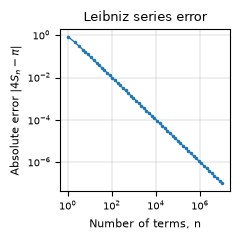

In [11]:
# Problem 4 - answer
import matplotlib.pyplot as plt

# About 60 values of n spaced evenly on a log scale from 1 to 10 million (n = 0 is excluded).
n_plot = np.unique(np.logspace(0, 7, 60).astype(int))
errors = [abs(4 * leibniz_numpy(n) - np.pi) for n in n_plot]

plt.figure(figsize=(2.5, 2.5))
plt.loglog(n_plot, errors, ".-", markersize=3, linewidth=1)
plt.xlabel("Number of terms, n", fontsize=8)
plt.ylabel(r"Absolute error $|4 S_n - \pi|$", fontsize=8)
plt.title("Leibniz series error", fontsize=9)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.grid(True, which="major", linewidth=0.3)
plt.tight_layout()
plt.show()

**Problem 5.** Would you do anything differently for computing $\pi$ using the Leibniz formula if you were using MATLAB instead of Python?

**Problem 5 - written answer:**

Yes. In MATLAB I would write the vectorized version directly, because arrays are MATLAB's basic data type and no separate library like NumPy is needed:

```matlab
k = 0:n-1;                     % row vector 0, 1, ..., n-1
terms = (-1).^k ./ (2*k + 1);  % element-wise power and division
approx_pi = 4 * sum(terms);
```

Differences I would watch for:

- **Vector construction:** `0:n-1` includes its end point, while `range(n)` and `np.arange(n)` stop before `n`. It is easy to end up with one term too many or too few when translating.
- **Element-wise operators:** MATLAB needs `.^` and `./`. Plain `^` and `/` are matrix operations and would give an error or a wrong result.
- **1-based indexing:** For the version that sums positive and negative terms separately, the positive terms are `terms(1:2:end)` and the negative terms are `terms(2:2:end)`, instead of Python's `x[::2]` and `x[1::2]`. In a loop over indices `i = 1:n`, the series index would be `k = i - 1`.
- **Vectorization vs. loops:** Vectorized code is the usual MATLAB style and normally the fastest, so I would use it. MATLAB compiles loops just in time, so a loop version is much less slow than a plain Python loop. If I did use a loop that stores the terms, I would set up the full array first with `zeros(1, n)` instead of growing it one element at a time.
- **Data structures:** The list, set and dictionary versions (2c–2e) have no natural MATLAB equivalent (cell arrays and `containers.Map` would be awkward here), so I would not write those versions at all.